# 06 — Cross-Task Synthesis
**Members B + D — joint notebook**

This is the *outstanding-project* differentiator: it ties **clustering**, **classification**, and **association rules** together to produce business-level insight that no single task could deliver:

- **Churn rate by segment** — which clusters are bleeding customers?
- **Anomalous customers by segment** — where does the autoencoder flag outliers?
- **Cluster-specific basket patterns** — what does each segment *actually* buy?
- **Headline finding** — segment-aware churn intervention recommendation.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import seed_all, savefig, DATA_PROCESSED, REPORTS_DIR
from src.plot_style import apply_style, PALETTE
from src import association as ar

seed_all(); apply_style()

In [2]:
df = pd.read_parquet(DATA_PROCESSED / 'transactions_clean.parquet')
rfm = pd.read_csv(DATA_PROCESSED / 'rfm_features.csv')
churn = pd.read_csv(DATA_PROCESSED / 'churn_labels.csv')
segments = pd.read_csv(DATA_PROCESSED / 'segments_kmeans.csv')
code_to_desc = (df.drop_duplicates('StockCode').set_index('StockCode')['Description'].to_dict())

merged = rfm.merge(segments, on='CustomerID').merge(churn, on='CustomerID', how='left')
merged['churn'] = merged['churn'].fillna(-1).astype(int)  # -1 means not in churn labelling window
merged.head()

,CustomerID,Recency,Frequency,Monetary,avg_basket_value,avg_basket_size,unique_products,DominantCountry,cluster,churn
0,12346,325,12,505.98,42.165,16.50,27,United Kingdom,1,1
1,12347,2,8,5517.80,689.725,396.75,126,Iceland,1,0
2,12348,75,5,1766.11,353.222,523.60,25,Finland,1,0
3,12349,18,4,3612.54,903.135,406.00,138,Italy,1,0
4,12350,310,1,309.35,309.350,197.00,17,Norway,0,1


## 1. Churn rate per segment

In [3]:
labelled = merged[merged['churn'] >= 0]
rate = labelled.groupby('cluster').agg(
    n_customers=('CustomerID','count'),
    churn_rate=('churn','mean'),
    avg_recency=('Recency','mean'),
    avg_frequency=('Frequency','mean'),
    avg_monetary=('Monetary','mean'),
).round(2).reset_index()
rate['churn_rate'] = (rate['churn_rate']*100).round(1)
rate.to_csv(REPORTS_DIR / 'cluster_churn_rate.csv', index=False)
rate

,cluster,n_customers,churn_rate,avg_recency,avg_frequency,avg_monetary
0,0,2697,90.0,367.87,1.96,519.53
1,1,2552,23.0,65.25,11.97,5401.23


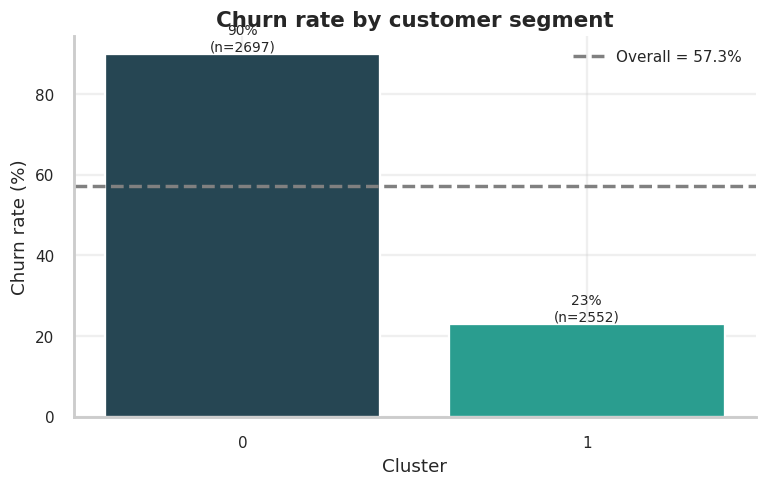

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [PALETTE[c % len(PALETTE)] for c in rate['cluster']]
bars = ax.bar(rate['cluster'].astype(str), rate['churn_rate'], color=colors)
for b, n, r in zip(bars, rate['n_customers'], rate['churn_rate']):
    ax.text(b.get_x()+b.get_width()/2, r, f'{r:.0f}%\n(n={n})', ha='center', va='bottom', fontsize=9)
overall = labelled['churn'].mean()*100
ax.axhline(overall, ls='--', color='gray', label=f'Overall = {overall:.1f}%')
ax.set_ylabel('Churn rate (%)'); ax.set_xlabel('Cluster')
ax.set_title('Churn rate by customer segment')
ax.legend(); savefig(fig, '06_churn_by_cluster'); plt.show()

## 2. Top product categories per segment (heatmap)

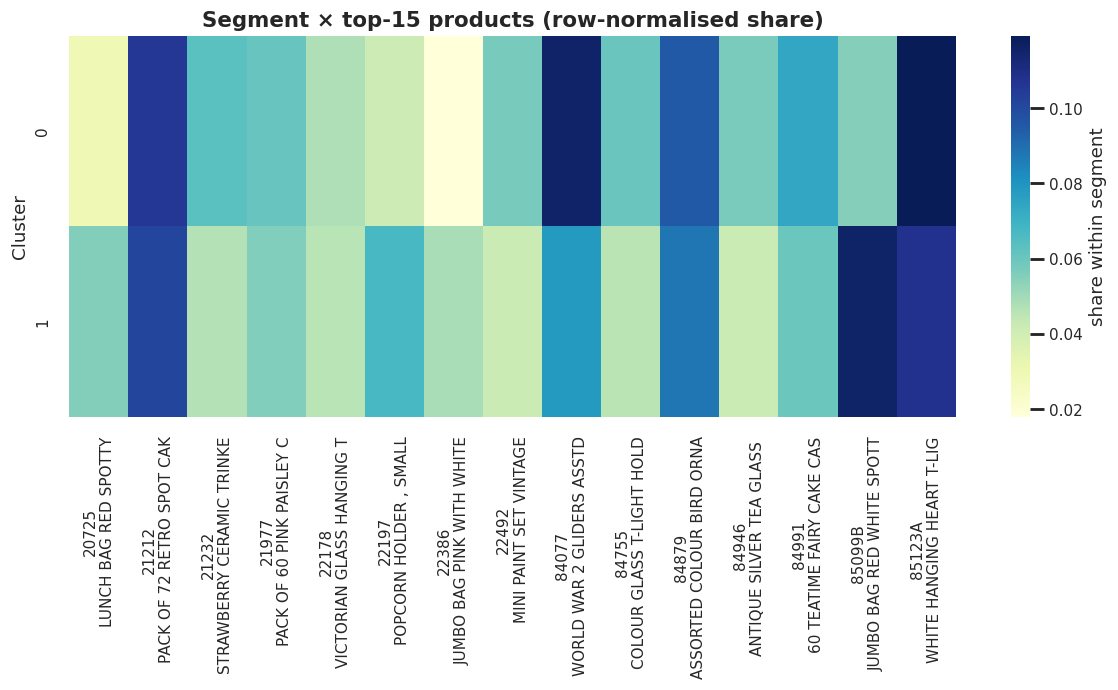

In [5]:
cust2cluster = dict(zip(segments['CustomerID'], segments['cluster']))
df_seg = df.copy(); df_seg['cluster'] = df_seg['CustomerID'].map(cust2cluster)
df_seg = df_seg.dropna(subset=['cluster']); df_seg['cluster'] = df_seg['cluster'].astype(int)

# Top-15 products overall
top_codes = (df_seg.groupby('StockCode')['Quantity'].sum().nlargest(15).index)
mat = (df_seg[df_seg['StockCode'].isin(top_codes)]
         .groupby(['cluster','StockCode'])['Quantity'].sum()
         .unstack(fill_value=0))
# Normalize by row to show share within segment
matn = mat.div(mat.sum(axis=1), axis=0)
matn.columns = [f"{c}\n{code_to_desc.get(c,'')[:25]}" for c in matn.columns]

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(matn, cmap='YlGnBu', ax=ax, cbar_kws={'label':'share within segment'})
ax.set_title('Segment × top-15 products (row-normalised share)')
ax.set_ylabel('Cluster')
savefig(fig, '06_segment_products_heatmap'); plt.show()

## 3. Cluster-specific association rules

In [6]:
per_cluster_rules = ar.cluster_specific_rules(
    df, cust2cluster, code_to_desc=code_to_desc,
    min_support=0.03, min_confidence=0.5, min_lift=1.5, top_n=10,
)
for c, rules in per_cluster_rules.items():
    print(f'\n--- Cluster {c} top rules ({len(rules)}) ---')
    if rules.empty:
        print('  (no rules at chosen thresholds)')
    else:
        display_cols = ['antecedents_desc','consequents_desc','support','confidence','lift']
        display(rules[display_cols].head(5))


--- Cluster 0 top rules (0) ---
  (no rules at chosen thresholds)

--- Cluster 1 top rules (3) ---


,antecedents_desc,consequents_desc,support,confidence,lift
0,LUNCHBAG PINK RETROSPOT,LUNCH BAG RED SPOTTY,0.030843,0.566529,7.406123
1,JUMBO BAG PINK WITH WHITE SPOTS,JUMBO BAG RED WHITE SPOTTY,0.032195,0.610874,6.386517
2,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,0.031969,0.709286,5.263049


In [7]:
# Persist combined per-cluster rules table
rows = []
for c, r in per_cluster_rules.items():
    if r.empty: continue
    r = r.copy(); r['cluster'] = c
    rows.append(r[['cluster','antecedents_desc','consequents_desc','support','confidence','lift']])
if rows:
    combined = pd.concat(rows, ignore_index=True)
    combined.to_csv(REPORTS_DIR / 'cluster_rules.csv', index=False)
    print(f'Wrote {len(combined)} cluster-specific rules to reports/cluster_rules.csv')

Wrote 3 cluster-specific rules to reports/cluster_rules.csv


## 4. Anomalous customers vs segment

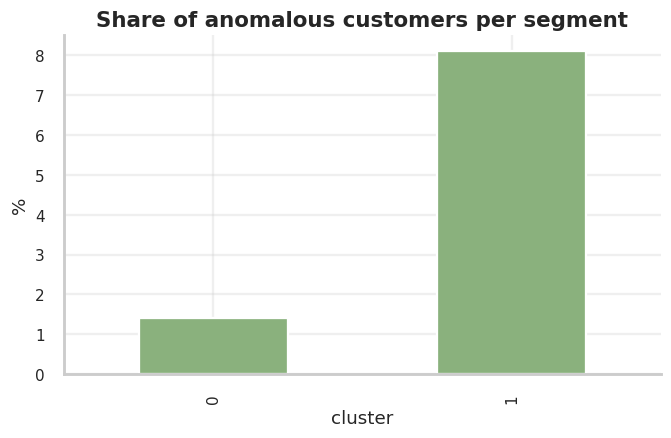

         anomaly_share_%
cluster                 
0                    1.4
1                    8.1


In [8]:
from pathlib import Path
anomaly_file = DATA_PROCESSED / 'anomalous_customers.csv'
if anomaly_file.exists():
    anom = pd.read_csv(anomaly_file)
    # anomalous_customers.csv now carries CustomerID -> merge cleanly on it.
    seg = segments.copy()
    seg['is_anomaly'] = seg['CustomerID'].isin(set(anom['CustomerID'])).astype(int)
    cross = seg.groupby('cluster')['is_anomaly'].mean().mul(100).round(1)
    fig, ax = plt.subplots(figsize=(7, 4))
    cross.plot.bar(ax=ax, color=PALETTE[5])
    ax.set_title('Share of anomalous customers per segment'); ax.set_ylabel('%')
    savefig(fig, '06_anomalies_by_cluster'); plt.show()
    print(cross.to_frame('anomaly_share_%'))
else:
    print('Run notebook 05 first to produce anomalous_customers.csv')

## 5. Headline finding
Replace the bullets below with the actual numbers after the pipeline runs.

- **Segment X** carries the highest churn rate (~Y%) while accounting for Z% of monetary value → priority retention targets.
- **Cluster-specific basket patterns** show Cluster A buys product pairs (P1 + P2) at high lift — cross-sell promotion candidate.
- **Anomalous customers** flagged by the autoencoder concentrate in Cluster B → manual outreach list.